# Causal effects

Does an indwelling arterial catheter, an arterial line, change whether a ventilated ICU patient is alive 28 days later?
An arterial line gives continuous blood pressure readings and easy access for blood gases, but it also carries risks of infection, bleeding and thrombosis.
This tutorial estimates its effect on 28-day mortality in the 1,776 mechanically ventilated, hemodynamically stable patients of the MIMIC-II IAC cohort, which was assembled for exactly this question ([Hsu et al., 2015](https://doi.org/10.1378/chest.15-0516)).
We check the assumptions behind an effect estimate from observational data, estimate the average effect with four estimators, compare them and look for patients in whom the effect differs.

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import pandas as pd

ep.settings.verbosity = "error"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
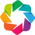

In [3]:
import holoviews as hv

hv.extension("bokeh")

## Data

The cohort holds one row per patient with demographics, comorbidities, the first vital signs and laboratory values in the ICU and the outcomes, so `.X` has a single timepoint.
`aline_flg` is 1 for patients who received an arterial line, and `day_28_flg` is 1 for patients who died within 28 days.
The care unit and the day of ICU admission are text, so we keep them in `obs`.

In [4]:
edata = ed.dt.mimic_2(columns_obs_only=["service_unit", "day_icu_intime"])
edata

EHRData object with n_obs × n_vars × n_t = 1776 × 44 × 1
    obs: 'service_unit', 'day_icu_intime'
    shape of .X: (1776, 44)

Without any adjustment, patients with an arterial line died more often.

In [5]:
df = ep.get.obs_df(edata, keys=["aline_flg", "day_28_flg", "sofa_first"])
df.groupby("aline_flg").agg(
    patients=("day_28_flg", "size"), died_pct=("day_28_flg", lambda died: round(100 * died.mean(), 1))
)

,patients,died_pct
aline_flg,,
0.0,792,14.3
1.0,984,17.3


The line did not go to random patients, though.
Grouping patients by their SOFA score at admission shows who received one.

In [6]:
edata.obs["SOFA"] = pd.cut(df["sofa_first"], bins=[-1, 3, 6, 9, 24], labels=["0-3", "4-6", "7-9", "10+"])
df.assign(SOFA=edata.obs["SOFA"]).groupby("SOFA", observed=True).agg(
    patients=("aline_flg", "size"),
    aline_pct=("aline_flg", lambda line: round(100 * line.mean(), 1)),
    died_pct=("day_28_flg", lambda died: round(100 * died.mean(), 1)),
)

,patients,aline_pct,died_pct
SOFA,,,
0-3,235,21.3,5.5
4-6,928,50.2,15.1
7-9,485,74.6,19.2
10+,122,85.2,27.9


The sicker a patient, the more likely they received a line and the more likely they died.
This confounding by indication makes the raw difference of 3 percentage points worthless as an estimate of what the line does.

## The question and its assumptions

We estimate the average treatment effect (ATE), the difference in 28-day mortality if all patients had received an arterial line versus if none had.
Since every patient is observed under only one of the two, the estimators fill in the other from comparable patients, which works only under three assumptions.

:::{admonition} Assumptions behind every estimate
:class: important
**Exchangeability**: given the covariates, who received a line is unrelated to the outcome they would have had, so no confounder is left unmeasured.
**Positivity**: every patient had a chance of both receiving and not receiving a line.
**Consistency**: a line is the same intervention in every patient, and one patient's line does not affect another patient's outcome.
:::

Only positivity can be checked in the data.
Exchangeability rests on the covariates we adjust for, which have to include everything that influenced both the decision to place a line and the risk of death: demographics, the care unit, the SAPS-I and SOFA scores, comorbidities and the first vital signs and laboratory values.

:::{warning}
Adjust only for variables measured before the treatment started.
The number of arterial blood gases (`abg_count`) rises because a line makes them easy to draw, and the ICU length of stay (`icu_los_day`) follows from the outcome, so adjusting for either removes part of the effect or adds bias.
:::

Weight and the SAPS-I score are missing for 6% and 5% of patients.
The estimators use only patients with all covariates, so we fill these few gaps with the median using {func}`~ehrapy.preprocessing.simple_impute`.
{func}`~ehrapy.preprocessing.scale_norm` then scales the continuous covariates.

:::{tip}
Scale continuous covariates before estimating effects.
The default outcome model is a regularized logistic regression, whose penalty depends on the units of the covariates.
:::

In [7]:
treatment = "aline_flg"
outcome = "day_28_flg"
continuous = [
    "age",
    "weight_first",
    "sapsi_first",
    "sofa_first",
    "map_1st",
    "hr_1st",
    "temp_1st",
    "spo2_1st",
    "wbc_first",
    "hgb_first",
    "platelet_first",
    "sodium_first",
    "potassium_first",
    "tco2_first",
    "chloride_first",
    "bun_first",
    "creatinine_first",
]
comorbidities = [
    "chf_flg",
    "afib_flg",
    "renal_flg",
    "liver_flg",
    "copd_flg",
    "cad_flg",
    "stroke_flg",
    "mal_flg",
    "resp_flg",
]
covariates = [*continuous, "gender_num", "service_unit", *comorbidities]

ep.pp.simple_impute(edata, var_names=[*continuous, "gender_num"], strategy="median")
ep.pp.scale_norm(edata, var_names=continuous)

## Positivity

{func}`~ehrapy.tools.positivity_check` fits a propensity model, the probability of receiving a line given the covariates, and reports the share of patients with a propensity between 0.05 and 0.95.
{func}`~ehrapy.plot.propensity_overlap` shows the distribution of the propensity in both groups.

In [8]:
positivity = ep.tl.positivity_check(edata, treatment=treatment, covariates=covariates)
ep.pl.propensity_overlap(positivity)

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Overlay
   .Histogram.Untreated :Histogram   [propensity_score]   (density)
   .Histogram.Treated   :Histogram   [propensity_score]   (density)
   .VLine.I             :VLine   [x,y]
   .VLine.II            :VLine   [x,y]

Both groups cover most of the range, and 93% of patients lie between the dashed lines.
The treated patients pile up close to 1, however, and a few untreated patients lie close to 0: given their covariates, these patients almost always or almost never received a line, so there are hardly any comparable patients in the other group.

## Inverse probability of treatment weighting

{func}`~ehrapy.tools.iptw` weights every patient by the inverse of the propensity of the treatment they received.
Patients who received a line although it was unlikely count more, which balances the covariates between the groups if the propensity model is right.
The confidence interval comes from refitting on 200 bootstrap samples.

:::{dropdown} How IPTW works
The weight of a treated patient is `1 / e(X)` and of an untreated patient `1 / (1 - e(X))`, where `e(X)` is the propensity.
Stabilized weights multiply both by the share of patients in their group, which keeps the estimate and reduces its variance.
The ATE is the difference of the weighted mean outcomes, and propensities are clipped to [0.01, 0.99] by default.
:::

In [9]:
est_iptw = ep.tl.iptw(edata, treatment=treatment, outcome=outcome, covariates=covariates, random_state=0)
print(est_iptw.summary())

Causal effect of 'aline_flg' on 'day_28_flg'
  method: iptw_stabilized
  ATE:    -0.0899
  SE:     0.0380
  95% CI: [-0.1697, -0.0246]
  n:      1776


{func}`~ehrapy.tools.covariate_balance` computes the standardized mean difference (SMD) of every covariate between the groups without and with the weights, and {func}`~ehrapy.plot.love_plot` shows them.
An absolute SMD below 0.1, inside the dashed lines, counts as balanced.

In [10]:
balance = ep.tl.covariate_balance(edata, treatment=treatment, covariates=covariates, weights=est_iptw.params["weights"])
ep.pl.love_plot(balance)

:Overlay
   .Segments.I         :Segments   [x0,y0,x1,y1]
   .Scatter.Unweighted :Scatter   [SMD]   (covariate)
   .Scatter.Weighted   :Scatter   [SMD]   (covariate)
   .VLine.I            :VLine   [x,y]
   .VLine.II           :VLine   [x,y]
   .VLine.III          :VLine   [x,y]

Before weighting, patients with a line had higher SOFA and SAPS-I scores and were more often in the surgical ICU (`service_unit_SICU`).
The weights remove most of these differences, but BUN, SAPS-I, hemoglobin, SOFA, the surgical ICU and the first mean arterial pressure stay just above 0.1.
How much the weights rely on single patients shows in the largest weight and the effective sample size, the number of unweighted patients that carry as much information as the weighted cohort.

In [11]:
weights = est_iptw.params["weights"]
effective_size = weights.sum() ** 2 / (weights**2).sum()
print(f"largest weight: {weights.max():.1f}, effective sample size: {effective_size:.0f} of {len(weights)}")

largest weight: 35.5, effective sample size: 688 of 1776


A single patient counts as much as 35 average patients, and the weighting leaves the information of fewer than 700 of the 1,776 patients.

:::{warning}
Extreme weights from propensities close to 0 or 1 let a handful of patients dominate the estimate.
Check the largest weight and the effective sample size, and restrict the cohort to common support when they are extreme.
:::

## G-computation, AIPW and matching

{func}`~ehrapy.tools.g_computation` takes the opposite route: it fits an outcome model of 28-day mortality given the treatment and the covariates, predicts the outcome of every patient with and without a line and averages the difference.

In [12]:
est_g = ep.tl.g_computation(edata, treatment=treatment, outcome=outcome, covariates=covariates, random_state=0)
print(est_g.summary())

Causal effect of 'aline_flg' on 'day_28_flg'
  method: g_computation
  ATE:    -0.0152
  SE:     0.0176
  95% CI: [-0.0512, 0.0188]
  n:      1776


{func}`~ehrapy.tools.aipw` combines both models.
It is consistent if either the propensity model or the outcome model is right, which is why it is called doubly robust, and its confidence interval needs no bootstrap.
Both models are cross-fitted: every patient gets the predictions of models fit on the other patients, which keeps the confidence interval valid.

:::{dropdown} How AIPW works
For every patient, AIPW starts from the g-computation contrast `μ1(X) - μ0(X)` and adds the residual of the observed outcome, weighted by the inverse propensity of the observed treatment.
If the outcome model is wrong, the weighted residuals correct it, and if the propensity model is wrong, the residuals are close to zero on average.
The mean of these values is the ATE, and their standard deviation gives the standard error.
:::

In [13]:
est_aipw = ep.tl.aipw(edata, treatment=treatment, outcome=outcome, covariates=covariates)
print(est_aipw.summary())

Causal effect of 'aline_flg' on 'day_28_flg'
  method: aipw
  ATE:    -0.0296
  SE:     0.0356
  95% CI: [-0.0993, 0.0402]
  n:      1776


{func}`~ehrapy.tools.propensity_score_matching` pairs every patient with the patient of the other group with the closest propensity and averages the differences in outcome within the pairs.

:::{note}
Matching estimates the effect in the treated patients (ATT) by default.
We set `target="ate"` so that all four estimators answer the same question.
:::

In [14]:
est_psm = ep.tl.propensity_score_matching(
    edata, treatment=treatment, outcome=outcome, covariates=covariates, target="ate", random_state=0
)
print(est_psm.summary())

Causal effect of 'aline_flg' on 'day_28_flg'
  method: propensity_score_matching_ate
  ATE:    -0.0716
  SE:     0.0269
  95% CI: [-0.1122, -0.0092]
  n:      1776


{func}`~ehrapy.plot.causal_effect` shows all four estimates with their 95% confidence intervals.

In [15]:
ep.pl.causal_effect(est_aipw, other={"iptw": est_iptw, "g_computation": est_g, "matching": est_psm})

:Overlay
   .Segments.I :Segments   [x0,y0,x1,y1]
   .Scatter.I  :Scatter   [effect]   (estimator)
   .VLine.I    :VLine   [x,y]

All four estimates are negative and far from the raw +3 percentage points, but they disagree.
IPTW and matching, which rely most on the propensity, suggest a protective effect of 7 to 9 percentage points with confidence intervals that exclude zero, while g-computation and AIPW find much smaller effects compatible with none.
Such disagreement is the signature of the poorly overlapping patients seen above.

## Restricting to common support

We drop the patients whose propensity lies outside [0.05, 0.95].
The estimand becomes the effect in patients for whom both choices were plausible, which are the patients in whom the decision is actually made.

In [16]:
propensity = positivity["propensity_scores"]
overlap = edata[(propensity >= 0.05) & (propensity <= 0.95)].copy()
overlap.n_obs

1655

In [17]:
est_iptw_overlap = ep.tl.iptw(overlap, treatment=treatment, outcome=outcome, covariates=covariates, random_state=0)
est_g_overlap = ep.tl.g_computation(
    overlap, treatment=treatment, outcome=outcome, covariates=covariates, random_state=0
)
est_aipw_overlap = ep.tl.aipw(overlap, treatment=treatment, outcome=outcome, covariates=covariates)
est_psm_overlap = ep.tl.propensity_score_matching(
    overlap, treatment=treatment, outcome=outcome, covariates=covariates, target="ate", random_state=0
)
balance_overlap = ep.tl.covariate_balance(
    overlap, treatment=treatment, covariates=covariates, weights=est_iptw_overlap.params["weights"]
)
weights = est_iptw_overlap.params["weights"]
print(f"largest weighted |SMD|: {balance_overlap['smd_weighted'].abs().max():.3f}, largest weight: {weights.max():.1f}")
ep.pl.causal_effect(
    est_aipw_overlap,
    other={"iptw": est_iptw_overlap, "g_computation": est_g_overlap, "matching": est_psm_overlap},
    title="Causal effect within common support",
)

largest weighted |SMD|: 0.076, largest weight: 11.7


:Overlay
   .Segments.I :Segments   [x0,y0,x1,y1]
   .Scatter.I  :Scatter   [effect]   (estimator)
   .VLine.I    :VLine   [x,y]

Within common support, the weights balance every covariate and the largest weight drops to about 12.
The four estimators now agree on an effect between -3.8 and -0.4 percentage points, and all confidence intervals include zero.
This matches the published analysis of this cohort, which found a 28-day mortality of 14.7% with and 15.2% without a line in propensity-matched patients, an odds ratio of 0.96 (95% CI 0.62-1.47) ([Hsu et al., 2015](https://doi.org/10.1378/chest.15-0516)).
The protective effect in the full cohort came from the few patients who almost always or almost never received a line.

:::{admonition} Which estimator to trust?
:class: tip
Use {func}`~ehrapy.tools.aipw` as the default, since it stays consistent if one of its two models is wrong.
Run IPTW and g-computation alongside, and if the estimates disagree, check overlap and weights before trusting any of them.
:::

The warning about post-treatment variables is easy to check: adjusting for the number of blood gases and the ICU length of stay moves the estimate.

In [18]:
est_post = ep.tl.aipw(
    overlap, treatment=treatment, outcome=outcome, covariates=[*covariates, "abg_count", "icu_los_day"]
)
print(est_post.summary())

Causal effect of 'aline_flg' on 'day_28_flg'
  method: aipw
  ATE:    0.0050
  SE:     0.0395
  95% CI: [-0.0724, 0.0824]
  n:      1655


The estimate shifts by about 1 percentage point towards harm, from -0.4 to +0.5 percentage points.
It no longer answers our question, since part of what the line changes is now held fixed.

## Does the effect differ between patients?

An average effect close to zero could hide benefit in some patients and harm in others.
Meta-learners estimate the conditional average treatment effect (CATE) of every patient from outcome models.
{func}`~ehrapy.tools.s_learner` fits one model with the treatment as a covariate, {func}`~ehrapy.tools.t_learner` fits one model per group, and {func}`~ehrapy.tools.x_learner` imputes the effect of every patient from the other group's model and combines both directions with the propensity ([Künzel et al., 2019](https://doi.org/10.1073/pnas.1804597116)).
We use gradient boosting as the outcome model, so that the effect can vary with the covariates, and `key_added` stores the CATE of every patient in `obs`.

In [19]:
ep.tl.s_learner(
    overlap,
    treatment=treatment,
    outcome=outcome,
    covariates=covariates,
    outcome_model="gradient_boosting",
    key_added="cate_s",
)
ep.tl.t_learner(
    overlap,
    treatment=treatment,
    outcome=outcome,
    covariates=covariates,
    outcome_model="gradient_boosting",
    key_added="cate_t",
)
ep.tl.x_learner(
    overlap,
    treatment=treatment,
    outcome=outcome,
    covariates=covariates,
    outcome_model="gradient_boosting",
    cate_model="gradient_boosting",
    key_added="cate_x",
)
overlap.obs.groupby("SOFA", observed=True)[["cate_s", "cate_t", "cate_x"]].agg(["mean", "std"]).round(3)

cate_s        cate_t        cate_x       
       mean    std   mean    std   mean    std
SOFA                                          
0-3    -0.0  0.002  0.015  0.150  0.008  0.083
4-6    -0.0  0.002  0.003  0.167  0.004  0.095
7-9    -0.0  0.007  0.011  0.220 -0.001  0.136
10+     0.0  0.000  0.030  0.311 -0.020  0.190

The S-learner estimates an effect of practically zero for every patient, because the boosted trees rarely split on a treatment whose effect is small.
The T- and X-learners give mean effects within 3 percentage points of zero in every SOFA group, without a trend towards the sicker patients.

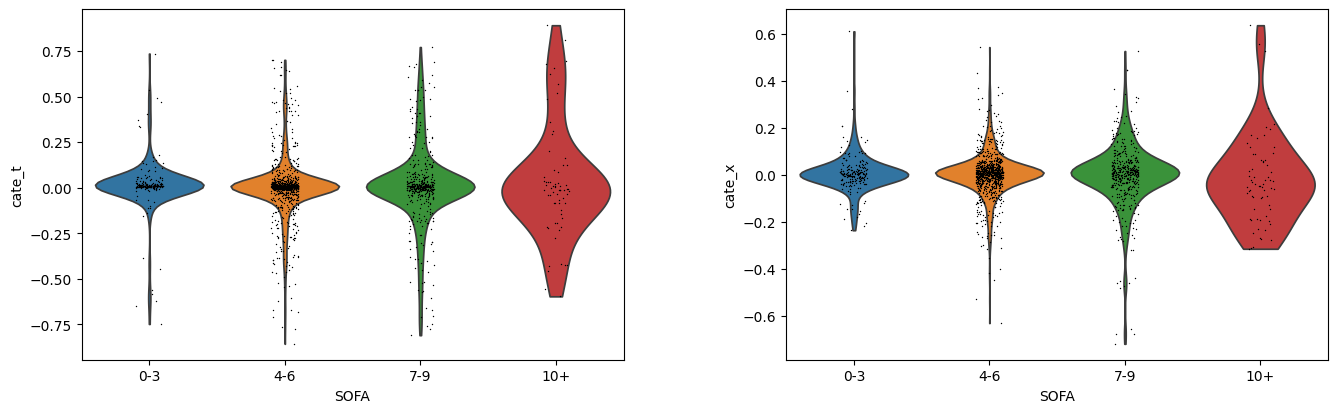

In [20]:
ep.pl.violin(overlap, keys=["cate_t", "cate_x"], groupby="SOFA", legend=False)

The individual effects spread widely, most of all in the few patients with a SOFA score of 10 or more.
With an average effect near zero and no trend across groups, this spread reflects how noisy the per-patient models are rather than patients who benefit or are harmed, and the X-learner, which borrows strength from both groups, spreads less than the T-learner.

:::{warning}
Per-patient effects from a single observational cohort are hypotheses.
A wide spread of CATEs can be pure model noise, so confirm any subgroup effect in independent data before acting on it.
:::

## Conclusion

Patients with an arterial line died more often, but only because sicker patients received one.
After adjusting for the severity at admission and restricting the cohort to patients with common support, IPTW, g-computation, AIPW and matching agree that an arterial line has no detectable effect on 28-day mortality in hemodynamically stable ventilated patients, in line with the published analysis of this cohort.
The meta-learners find no subgroup in which the effect differs, and the per-patient estimates are in `obs["cate_x"]` for further analyses.

:::{seealso}
All causal estimators and diagnostics are listed in the {doc}`tools API </api/tools_index>`.
:::